# Bayesian GP Fitting Diagnostic: Compressible Euler

**Goal:** Fit a Bayesian GP to the noisy POD coefficients *in isolation* — no operator,
no ODE constraint, no physics. If we can't fit the GP here, no joint model will work.

Tweak priors, learning rates, and scaling below until the GP tracks the data.

In [80]:
import sys
sys.path.insert(0, '../..')

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, Predictive, autoguide
from numpyro.optim import Adam, ClippedAdam
from jax import random
import time

from core import (
    generate_trajectory,
    DataScaler,
    extract_gp_posterior,
    fit_gp_hyperparameters_mle,
)

sys.path.insert(0, '../euler')
import config
from config import Basis

numpyro.set_platform('cpu')
numpyro.set_host_device_count(4)

np.random.seed(42)
rng_key = random.PRNGKey(42)

## 1. Configuration

In [81]:
# === DATA ===
TRAINING_SPAN = (0, 0.08)
PREDICTION_SPAN = (0, config.time_domain[-1])
NUM_SAMPLES = 250
NOISE_LEVEL = 0.03
NUM_MODES = 6
USE_SCALED_DATA = True

# === GP PRIORS (LogNormal) ===
# Lengthscale: prior centered at T/20 — tune loc and scale here
GP_LENGTHSCALE_PRIOR_LOC = None   # defaults to log(T/20)
GP_LENGTHSCALE_PRIOR_SCALE = 0.5

# Signal variance: prior centered at empirical variance
GP_VARIANCE_PRIOR_LOC = None      # defaults to log(var(data))
GP_VARIANCE_PRIOR_SCALE = 0.5

# Noise: prior centered at data-driven estimate
GP_NOISE_PRIOR_LOC = None         # computed per-mode below
GP_NOISE_PRIOR_SCALE = 0.5      # can be looser now — marginal likelihood self-regularizes

# === SVI ===
NUM_SVI_STEPS = 5000    # marginal likelihood converges fast
LEARNING_RATE = 5e-3     # aggressive — pure GP should converge fast
NUM_POSTERIOR_SAMPLES = 500

# === PLOTTING ===
NUM_REGRESSION_POINTS = 150

## 2. Generate Training Data

In [82]:
(fom, time_domain_full, true_states, time_sampled, snapshots_sampled) = \
    generate_trajectory(config, config.time_domain, TRAINING_SPAN, NUM_SAMPLES, NOISE_LEVEL)

basis = Basis(num_vectors=NUM_MODES)
basis.fit(snapshots_sampled)
snapshots_comp_sampled = basis.compress(snapshots_sampled)
full_states_compressed = basis.compress(true_states)

time_domain_eval = np.linspace(TRAINING_SPAN[0], TRAINING_SPAN[1], NUM_REGRESSION_POINTS)

print(f"Training span: [{TRAINING_SPAN[0]}, {TRAINING_SPAN[1]}], T = {TRAINING_SPAN[1]-TRAINING_SPAN[0]}")
print(f"Snapshots: {snapshots_comp_sampled.shape} ({NUM_MODES} modes × {NUM_SAMPLES} points)")
print(f"Cumulative energy: {basis.cumulative_energy:.4%}")

generating training data...done in 0.96 s.
Training span: [0, 0.08], T = 0.08
Snapshots: (6, 250) (6 modes × 250 points)
Cumulative energy: 88.2756%


In [83]:
if USE_SCALED_DATA:
    data_scaler = DataScaler(num_modes=NUM_MODES)
    data_scaler.fit(snapshots_comp_sampled)
    training_data = data_scaler.transform(snapshots_comp_sampled)
    print(f"Scaling enabled: {data_scaler}")
else:
    data_scaler = None
    training_data = snapshots_comp_sampled
    print("Scaling disabled: using raw POD coefficients")

per_mode_noise_var = np.array([
    (NOISE_LEVEL * np.std(snapshots_comp_sampled[i])) ** 2
    for i in range(NUM_MODES)
])
if USE_SCALED_DATA:
    per_mode_noise_var_scaled = np.array([
        per_mode_noise_var[i] / data_scaler.stds_[i, 0]**2
        for i in range(NUM_MODES)
    ])
    GP_NOISE_PRIOR_LOC = np.log(per_mode_noise_var_scaled)
else:
    GP_NOISE_PRIOR_LOC = np.log(per_mode_noise_var)

print("\nPer-mode priors:")
for i in range(NUM_MODES):
    print(f"  Mode {i}: noise_var={np.exp(GP_NOISE_PRIOR_LOC[i]):.6f}, "
          f"log(noise_var)={GP_NOISE_PRIOR_LOC[i]:.3f}")

Scaling enabled: DataScaler(num_modes=6, fitted=True, mean_range=[-4.974e-17, 1.386e-16], std_range=[1.993e-01, 4.724e-01])

Per-mode priors:
  Mode 0: noise_var=0.000900, log(noise_var)=-7.013
  Mode 1: noise_var=0.000900, log(noise_var)=-7.013
  Mode 2: noise_var=0.000900, log(noise_var)=-7.013
  Mode 3: noise_var=0.000900, log(noise_var)=-7.013
  Mode 4: noise_var=0.000900, log(noise_var)=-7.013
  Mode 5: noise_var=0.000900, log(noise_var)=-7.013


## 3. MLE Baseline (sanity check)

First fit a standard MLE GP to verify the data is fittable.

Fitting GP hyperparameters via MLE...
  L=0.0049, V=2.6887, N=0.000842
  Mode 0: L=0.0049, V=2.6887, N=0.000842
  L=0.0047, V=3.7465, N=0.001248
  Mode 1: L=0.0047, V=3.7465, N=0.001248
  L=0.0049, V=3.3794, N=0.000949
  Mode 2: L=0.0049, V=3.3794, N=0.000949
  L=0.0053, V=2.7279, N=0.001300
  Mode 3: L=0.0053, V=2.7279, N=0.001300
  L=0.0049, V=8.0473, N=0.001582
  Mode 4: L=0.0049, V=8.0473, N=0.001582
  L=0.0042, V=3.3355, N=0.003926
  Mode 5: L=0.0042, V=3.3355, N=0.003926


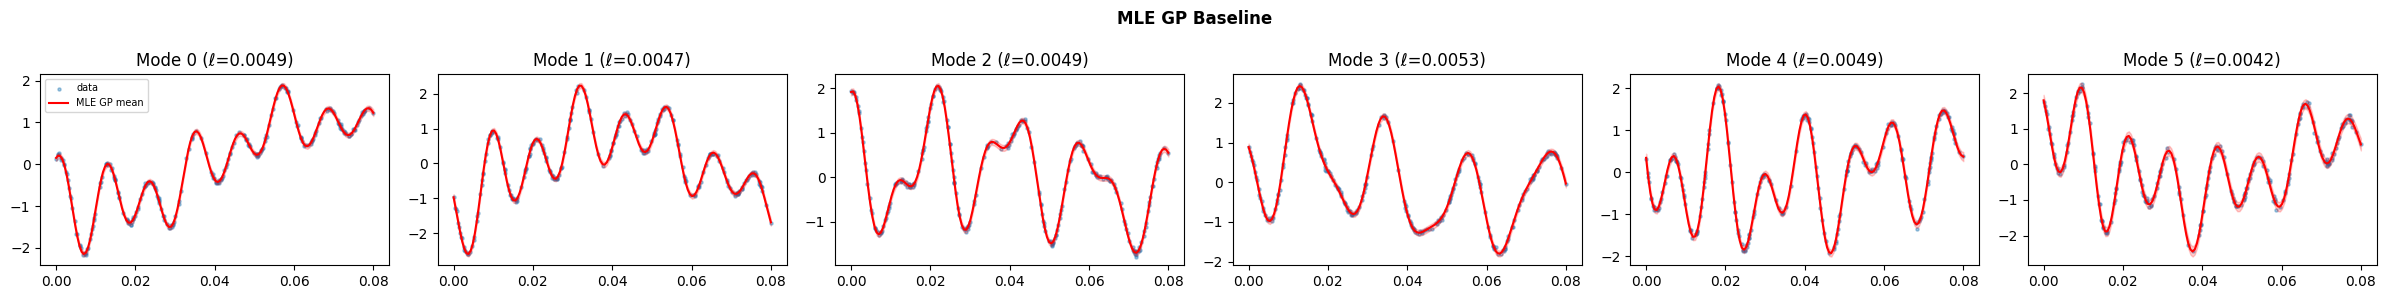

In [84]:
Ls, Vs, Ns, gp_models = fit_gp_hyperparameters_mle(
    time_domain=time_sampled,
    snapshots=training_data,
    verbose=True,
)

fig, axes = plt.subplots(1, NUM_MODES, figsize=(4 * NUM_MODES, 3), sharex=True)
if NUM_MODES == 1:
    axes = [axes]
for i in range(NUM_MODES):
    mean, std = gp_models[i].predict(time_domain_eval.reshape(-1, 1))
    axes[i].scatter(time_sampled, training_data[i], s=5, alpha=0.4, label='data')
    axes[i].plot(time_domain_eval, mean, 'r-', lw=1.5, label='MLE GP mean')
    axes[i].fill_between(time_domain_eval, mean - 2*std, mean + 2*std, alpha=0.2, color='r')
    axes[i].set_title(f'Mode {i} (ℓ={Ls[i]:.4f})')
    if i == 0:
        axes[i].legend(fontsize=7)
fig.suptitle('MLE GP Baseline', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Bayesian GP Model (marginal likelihood — no X sampling)

Instead of sampling `X_raw` and computing `X = L @ X_raw` (which creates a 250-dim
funnel that AutoNormal can't navigate), we use the GP marginal likelihood:

$$y \sim \mathcal{N}(0, K(\ell, \sigma^2) + \nu I)$$

This analytically marginalizes out X, leaving only 3 hyperparameters per mode
(18 total). X is recovered afterwards via the GP conditional mean.

In [85]:
def build_marginal_gp_model(
    time_sampled, training_data, num_modes,
    gp_lengthscale_prior_loc=None, gp_lengthscale_prior_scale=0.5,
    gp_variance_prior_loc=None, gp_variance_prior_scale=0.5,
    gp_noise_prior_loc=None, gp_noise_prior_scale=0.5,
    jitter=1e-5,
):
    """
    Bayesian GP with X analytically marginalized out.

    Instead of sampling X_raw and computing X = L @ X_raw, we use the
    GP marginal likelihood: y ~ N(0, K + νI). This eliminates the 250-dim
    latent space per mode, leaving only 3 hyperparameters per mode for SVI.
    """
    t = jnp.array(time_sampled)
    n = len(t)
    y = jnp.array(training_data)
    T = float(t[-1]) - float(t[0])

    if gp_lengthscale_prior_loc is None:
        _ls_loc = jnp.full(num_modes, jnp.log(T / 20.0))
    else:
        _ls_loc = jnp.broadcast_to(jnp.asarray(gp_lengthscale_prior_loc), (num_modes,))
    if gp_variance_prior_loc is None:
        _var_loc = jnp.array([jnp.log(jnp.var(y[i]) + 1e-8) for i in range(num_modes)])
    else:
        _var_loc = jnp.broadcast_to(jnp.asarray(gp_variance_prior_loc), (num_modes,))
    if gp_noise_prior_loc is None:
        _noise_loc = jnp.full(num_modes, -8.0)
    else:
        _noise_loc = jnp.broadcast_to(jnp.asarray(gp_noise_prior_loc), (num_modes,))

    _ls_scale = gp_lengthscale_prior_scale
    _var_scale = gp_variance_prior_scale
    _noise_scale = gp_noise_prior_scale
    _jitter = jitter

    sq_diffs = (t[:, None] - t[None, :]) ** 2
    I_n = jnp.eye(n)

    def model():
        for i in range(num_modes):
            ell = numpyro.sample(f"lengthscale_{i}",
                                 dist.LogNormal(_ls_loc[i], _ls_scale))
            sig2 = numpyro.sample(f"variance_{i}",
                                  dist.LogNormal(_var_loc[i], _var_scale))
            nu = numpyro.sample(f"noise_{i}",
                                dist.LogNormal(_noise_loc[i], _noise_scale))

            # Marginal likelihood: y ~ N(0, K + νI)
            # X is analytically marginalized — no X_raw sampling needed
            K = sig2 * jnp.exp(-sq_diffs / (2.0 * ell**2))
            K_y = K + (nu + _jitter) * I_n
            numpyro.sample(f"obs_{i}",
                           dist.MultivariateNormal(jnp.zeros(n), covariance_matrix=K_y),
                           obs=y[i])

    return model


def recover_gp_posterior(samples, time_sampled, training_data, num_modes, jitter=1e-5):
    """
    Given posterior hyperparameter samples, recover X via the GP conditional mean.
    X_mean = K @ (K + νI)^{-1} y  for each posterior sample.
    """
    t = jnp.array(time_sampled)
    n = len(t)
    sq_diffs = (t[:, None] - t[None, :]) ** 2
    I_n = jnp.eye(n)

    results = {}
    for i in range(num_modes):
        ells = samples[f"lengthscale_{i}"]
        sig2s = samples[f"variance_{i}"]
        nus = samples[f"noise_{i}"]
        y_i = jnp.array(training_data[i])
        num_samples = len(ells)

        X_all = []
        for s in range(num_samples):
            K = sig2s[s] * jnp.exp(-sq_diffs / (2.0 * ells[s]**2))
            K_y = K + (nus[s] + jitter) * I_n
            L = jnp.linalg.cholesky(K_y)
            alpha = jax.scipy.linalg.cho_solve((L, True), y_i)
            X_mean = K @ alpha
            X_all.append(X_mean)

        results[f"X_{i}"] = jnp.stack(X_all)
    return results

print("Marginal likelihood GP model defined.")

Marginal likelihood GP model defined.


## 5. Run SVI

100%|██████████| 5000/5000 [00:24<00:00, 203.84it/s, init loss: 3686.2837, avg. loss [4751-5000]: -2119.9258]



SVI completed in 25.3s (18 params: 3 hyperparams × 6 modes)


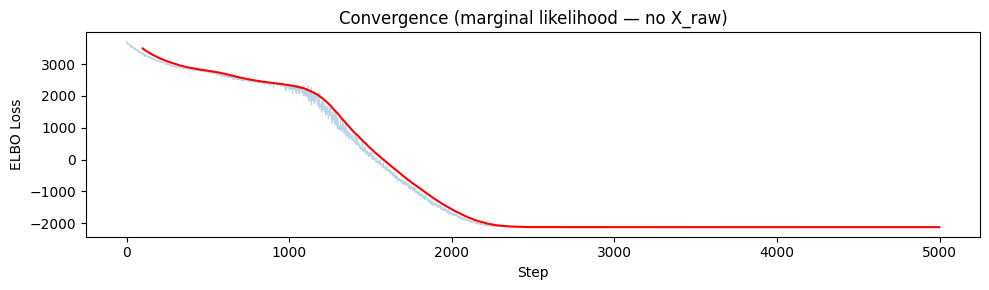

Final loss: -2115.3


In [86]:
gp_model = build_marginal_gp_model(
    time_sampled=time_sampled,
    training_data=training_data,
    num_modes=NUM_MODES,
    gp_lengthscale_prior_loc=GP_LENGTHSCALE_PRIOR_LOC,
    gp_lengthscale_prior_scale=GP_LENGTHSCALE_PRIOR_SCALE,
    gp_variance_prior_loc=GP_VARIANCE_PRIOR_LOC,
    gp_variance_prior_scale=GP_VARIANCE_PRIOR_SCALE,
    gp_noise_prior_loc=GP_NOISE_PRIOR_LOC,
    gp_noise_prior_scale=GP_NOISE_PRIOR_SCALE,
)

guide = autoguide.AutoNormal(gp_model)
optimizer = ClippedAdam(step_size=LEARNING_RATE)
svi = SVI(gp_model, guide, optimizer, loss=Trace_ELBO())

rng_key, init_key, sample_key = random.split(rng_key, 3)

t0 = time.time()
svi_result = svi.run(init_key, NUM_SVI_STEPS, progress_bar=True)
elapsed = time.time() - t0
print(f"\nSVI completed in {elapsed:.1f}s ({NUM_MODES * 3} params: 3 hyperparams × {NUM_MODES} modes)")

# Loss curve
fig, ax = plt.subplots(figsize=(10, 3))
losses = svi_result.losses
ax.plot(losses, alpha=0.3, lw=0.5)
window = min(100, len(losses) // 10)
if window > 1:
    smoothed = np.convolve(losses, np.ones(window)/window, mode='valid')
    ax.plot(np.arange(window-1, window-1+len(smoothed)), smoothed, 'r-', lw=1.5)
ax.set_xlabel('Step')
ax.set_ylabel('ELBO Loss')
ax.set_title('Convergence (marginal likelihood — no X_raw)')
plt.tight_layout()
plt.show()
print(f"Final loss: {losses[-1]:.1f}")

## 6. Results

Mode   ℓ (median)     σ² (median)    ν (median)     T/ℓ     
--------------------------------------------------------
0      0.004652       1.800061       0.000839       17.2    
1      0.004328       2.127563       0.001243       18.5    
2      0.004471       1.919716       0.000947       17.9    
3      0.005022       1.810478       0.001298       15.9    
4      0.004248       2.729714       0.001529       18.8    
5      0.003787       2.080553       0.003710       21.1    


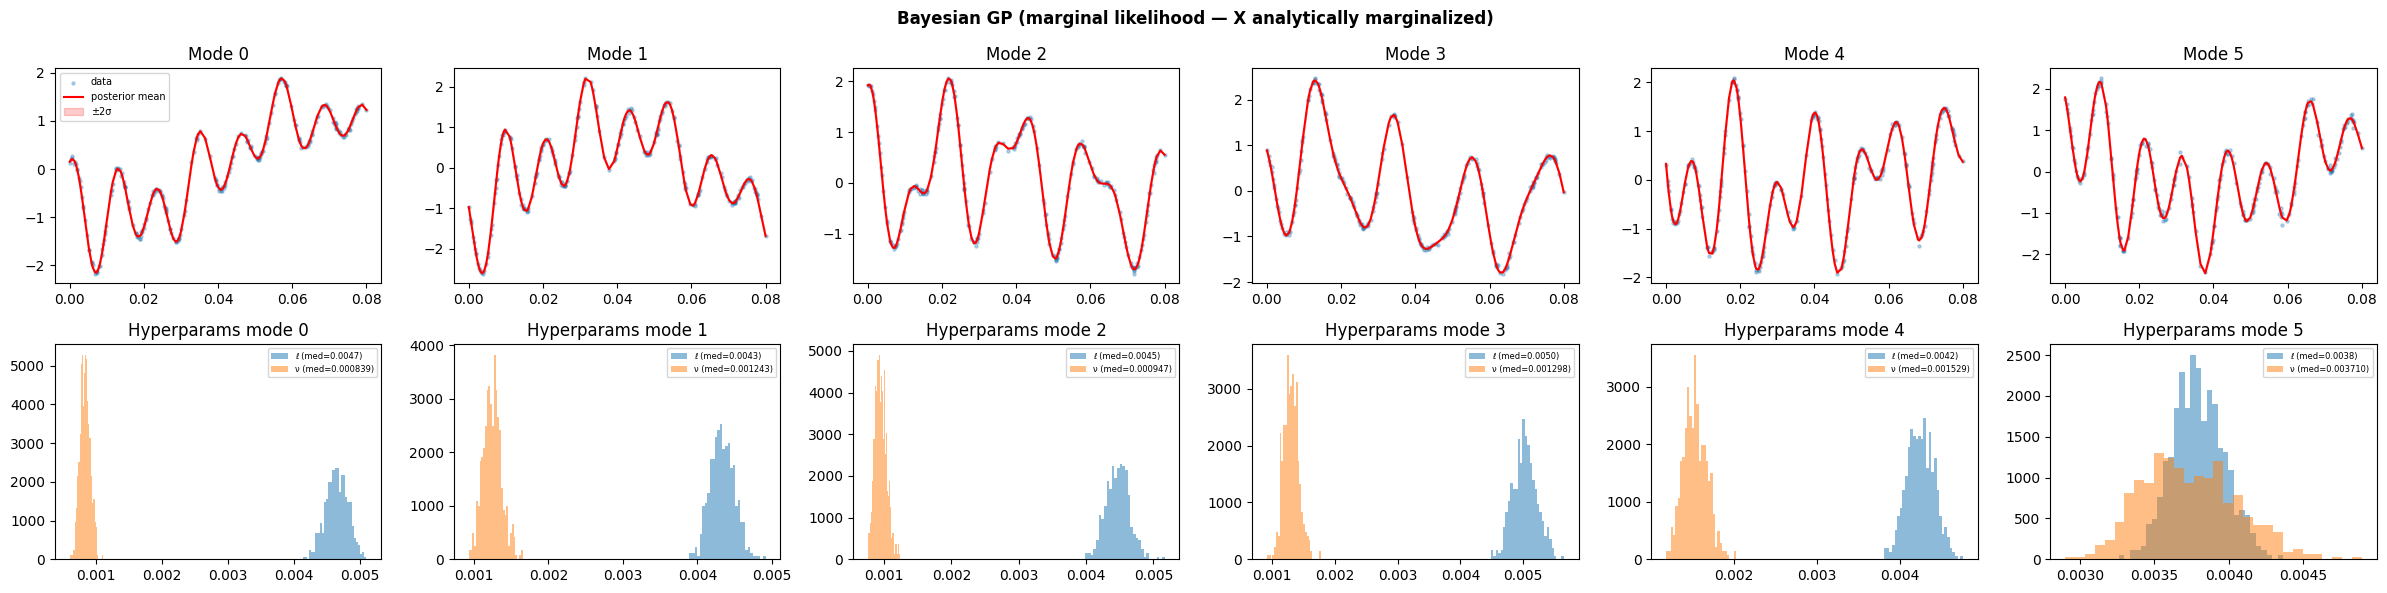

In [87]:
# Sample hyperparameter posteriors
_return_sites = [s for i in range(NUM_MODES)
                 for s in [f"lengthscale_{i}", f"variance_{i}", f"noise_{i}"]]
predictive = Predictive(gp_model, guide=guide, params=svi_result.params,
                        num_samples=NUM_POSTERIOR_SAMPLES, return_sites=_return_sites)
samples = predictive(sample_key)

# Recover X via GP conditional mean for each posterior sample
x_samples = recover_gp_posterior(samples, time_sampled, training_data, NUM_MODES)
samples.update(x_samples)

# --- Plot ---
fig, axes = plt.subplots(2, NUM_MODES, figsize=(4 * NUM_MODES, 6))
if NUM_MODES == 1:
    axes = axes.reshape(2, 1)

T = TRAINING_SPAN[1] - TRAINING_SPAN[0]
print(f"{'Mode':<6} {'ℓ (median)':<14} {'σ² (median)':<14} {'ν (median)':<14} {'T/ℓ':<8}")
print("-" * 56)

for i in range(NUM_MODES):
    ax = axes[0, i]
    X_samples = np.array(samples[f"X_{i}"])
    X_mean = np.mean(X_samples, axis=0)
    X_std = np.std(X_samples, axis=0)

    ax.scatter(time_sampled, training_data[i], s=5, alpha=0.3, label='data')
    ax.plot(time_sampled, X_mean, 'r-', lw=1.5, label='posterior mean')
    ax.fill_between(time_sampled, X_mean - 2*X_std, X_mean + 2*X_std,
                    alpha=0.2, color='r', label='±2σ')
    ax.set_title(f'Mode {i}')
    if i == 0:
        ax.legend(fontsize=7)

    # Hyperparameter histograms
    ax2 = axes[1, i]
    ell_samples = samples[f"lengthscale_{i}"]
    nu_samples = samples[f"noise_{i}"]
    ax2.hist(np.array(ell_samples), bins=30, alpha=0.5,
             label=f'ℓ (med={np.median(ell_samples):.4f})', density=True)
    ax2.hist(np.array(nu_samples), bins=30, alpha=0.5,
             label=f'ν (med={np.median(nu_samples):.6f})', density=True)
    ax2.legend(fontsize=6)
    ax2.set_title(f'Hyperparams mode {i}')

    ell = float(np.median(ell_samples))
    sig2 = float(np.median(samples[f"variance_{i}"]))
    nu = float(np.median(nu_samples))
    print(f"{i:<6} {ell:<14.6f} {sig2:<14.6f} {nu:<14.6f} {T/ell:<8.1f}")

fig.suptitle('Bayesian GP (marginal likelihood — X analytically marginalized)', fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Diagnosis

**What to look for:**
- **Top row:** Does the red GP mean track the data oscillations? If flat → GP is over-smoothing.
- **Bottom row:** Are lengthscales reasonable? ℓ should be ≪ T (the T/ℓ column should be > 5).
  If ℓ ≈ T, the GP is essentially fitting a constant.
- **Noise:** ν should be close to the data-driven prior, not orders of magnitude larger.

**If the GP is still flat, try:**
1. Tighter lengthscale prior: decrease `GP_LENGTHSCALE_PRIOR_SCALE` (e.g., 0.25)
2. Tighter noise prior: decrease `GP_NOISE_PRIOR_SCALE` (e.g., 0.1)
3. More steps: increase `NUM_SVI_STEPS` to 10000+
4. Initialise from MLE: set `GP_LENGTHSCALE_PRIOR_LOC` to `np.log(Ls)` from the MLE fit above